# РГР — Обучение и сериализация моделей ML
## Датасет: Diabetes Health Indicators

**Целевая переменная:** `Diabetes_012` (0 — нет диабета, 1 — предиабет, 2 — диабет 2 типа)

### Логика работы ноутбука
Каждая модель проверяет наличие готового `.pkl`-файла:
- Если файл **найден** → загружается и выводятся метрики (без обучения)
- Если файл **не найден** → модель обучается и сохраняется

| # | Тип | Модель | Откуда берётся |
|---|---|---|---|
| ML1 | Классическая | DecisionTreeClassifier | обучается здесь |
| ML2 | Бустинг | GradientBoostingClassifier | обучается здесь |
| ML3 | Продвинутый бустинг | CatBoostClassifier | обучается здесь |
| ML4 | Бэггинг | BaggingClassifier | обучается здесь |
| ML5 | Стэкинг | StackingClassifier | обучается здесь |
| ML6 | Нейронная сеть | MLPClassifier | обучается здесь |

## 1. Импорт библиотек

In [19]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier, BaggingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


## 2. Конфигурация путей

> ⚙️ **Измени `DATA_PATH` и `MODELS_DIR` если нужно**

In [20]:
DATA_PATH  = "datasets/filtered_diabetes_health_indicators.csv"
MODELS_DIR = "models"

MODEL_PATHS = {
    "ML1_DecisionTree":      os.path.join(MODELS_DIR, "dt_classifier_model.pkl"),
    "ML2_GradientBoosting":  os.path.join(MODELS_DIR, "gb_classifier_model.pkl"),
    "ML3_CatBoost":          os.path.join(MODELS_DIR, "cb_classifier_model.pkl"),
    "ML4_Bagging":           os.path.join(MODELS_DIR, "bag_classifier_model.pkl"),
    "ML5_Stacking":          os.path.join(MODELS_DIR, "stack_classifier_model.pkl"),
    "ML6_NeuralNetwork":     os.path.join(MODELS_DIR, "nn_classifier_model.pkl"),
}

os.makedirs(MODELS_DIR, exist_ok=True)

print("📂 Папка для моделей:", os.path.abspath(MODELS_DIR))
print("Текущий статус файлов:")
for name, path in MODEL_PATHS.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "—"
    icon   = "✅ готова" if exists else "⏳ нужно обучить"
    print(f"  {icon}  {name:<28} {size}")

📂 Папка для моделей: /home/alexey-rau/projects/omgtu/diabetes-ml-dashboard/models
Текущий статус файлов:
  ✅ готова  ML1_DecisionTree             162.8 KB
  ✅ готова  ML2_GradientBoosting         393.5 KB
  ✅ готова  ML3_CatBoost                 425.3 KB
  ✅ готова  ML4_Bagging                  93182.4 KB
  ✅ готова  ML5_Stacking                 31597.7 KB
  ✅ готова  ML6_NeuralNetwork            268.8 KB


## 3. Загрузка и подготовка данных

In [21]:
df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
df.head()

Размер датасета: 229,718 строк × 22 столбцов


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [22]:
print(f"Пропущенных значений: {df.isnull().sum().sum()}")
print(f"Дубликатов: {df.duplicated().sum()}")
print("Распределение классов (Diabetes_012):")
print(df["Diabetes_012"].value_counts().rename({0: "Нет диабета", 1: "Предиабет", 2: "Диабет 2 типа"}))

Пропущенных значений: 0
Дубликатов: 0
Распределение классов (Diabetes_012):
Diabetes_012
Нет диабета      189994
Диабет 2 типа     35095
Предиабет          4629
Name: count, dtype: int64


In [23]:
X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}  |  Признаков: {X_train.shape[1]}")

Train: 183,774  |  Test: 45,944  |  Признаков: 21


## 4. Вспомогательные функции

In [24]:
def make_pipeline(estimator):
    return Pipeline([("scaler", StandardScaler()), ("model", estimator)])


def print_metrics(name, y_true, y_pred):
    metrics = {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-macro" : f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    print(f"  📊 {name} — Hold-out метрики:")
    for k, v in metrics.items():
        print(f"     {k:<12}: {v:.4f}")
    return metrics


def run_kfold(name, model, X, y, cv):
    scores = cross_validate(
        model, X, y, cv=cv, n_jobs=-1,
        scoring=["accuracy", "f1_macro", "precision_macro", "recall_macro"]
    )
    print(f"  📊 {name} — K-fold (mean ± std):")
    for k, v in scores.items():
        if k.startswith("test_"):
            print(f"     {k[5:]:<22}: {v.mean():.4f} ± {v.std():.4f}")
    return scores


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Нет", "Предиабет", "Диабет 2"],
                yticklabels=["Нет", "Предиабет", "Диабет 2"])
    ax.set(xlabel="Предсказано", ylabel="Факт", title=title)
    plt.tight_layout()
    plt.show()


def train_or_load(key, model_factory, X_tr, y_tr, X_ts, y_ts, X_full, y_full, cv,
                  run_kfold_flag=True):

    path = MODEL_PATHS[key]
    name = key.replace("_", " ")

    if os.path.exists(path):
        print(f"📂 {name}: загружаем готовую модель ({os.path.getsize(path)/1024:.1f} KB)")
        model = joblib.load(path)
    else:
        print(f"🔨 {name}: обучаем...")
        model = model_factory()
        model.fit(X_tr, y_tr)
        joblib.dump(model, path)
        print(f"💾 Сохранена: {path}")

    y_pred = np.array(model.predict(X_ts)).flatten().astype(int)
    metrics = print_metrics(name, y_ts, y_pred)
    plot_confusion(y_ts, y_pred, f"{name} — Confusion Matrix")
    print(classification_report(y_ts, y_pred,
          target_names=["Нет диабета", "Предиабет", "Диабет 2 типа"]))

    if run_kfold_flag:
        run_kfold(name, model, X_full, y_full, cv)

    return model, metrics


results_summary = {}
print("✅ Функции определены")

✅ Функции определены


## 5. ML1 — DecisionTreeClassifier

**Тип:** Классическая модель обучения с учителем  
**Описание:** Дерево решений строит правила классификации путём рекурсивного разбиения пространства признаков по критерию Джини.  
**Гиперпараметры:** подобраны в Lab4 с помощью GridSearchCV, F1-macro = 0.4012

📂 ML1 DecisionTree: загружаем готовую модель (162.8 KB)
  📊 ML1 DecisionTree — Hold-out метрики:
     Accuracy    : 0.5738
     Precision   : 0.4344
     Recall      : 0.4764
     F1-macro    : 0.3950


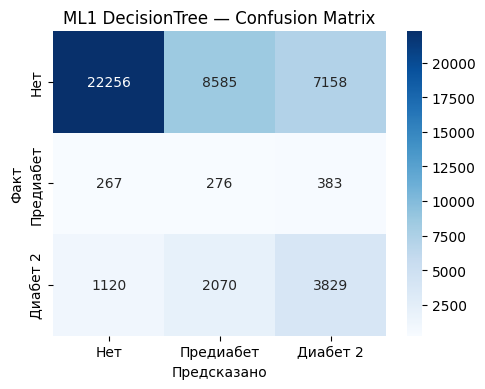

               precision    recall  f1-score   support

  Нет диабета       0.94      0.59      0.72     37999
    Предиабет       0.03      0.30      0.05       926
Диабет 2 типа       0.34      0.55      0.42      7019

     accuracy                           0.57     45944
    macro avg       0.43      0.48      0.40     45944
 weighted avg       0.83      0.57      0.66     45944

  📊 ML1 DecisionTree — K-fold (mean ± std):
     accuracy              : 0.5599 ± 0.0086
     f1_macro              : 0.3917 ± 0.0035
     precision_macro       : 0.4341 ± 0.0019
     recall_macro          : 0.4870 ± 0.0069


In [25]:
model_dt, res_dt = train_or_load(
    key          = "ML1_DecisionTree",
    model_factory= lambda: make_pipeline(DecisionTreeClassifier(
        criterion="gini", max_depth=10, min_samples_leaf=1,
        class_weight="balanced", random_state=42
    )),
    X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test,
    X_full=X, y_full=y, cv=skf
)
results_summary["ML1 DecisionTree"] = res_dt

## 6. ML2 — GradientBoostingClassifier (бустинг)

**Тип:** Ансамблевая модель — бустинг  
**Описание:** Последовательно строит деревья, каждое исправляет ошибки предыдущего путём оптимизации функции потерь по градиенту.  
**Гиперпараметры:** подобраны в Lab4 с помощью RandomizedSearchCV, F1-macro = 0.4179

📂 ML2 GradientBoosting: загружаем готовую модель (393.5 KB)
  📊 ML2 GradientBoosting — Hold-out метрики:
     Accuracy    : 0.8361
     Precision   : 0.4733
     Recall      : 0.3900
     F1-macro    : 0.3998


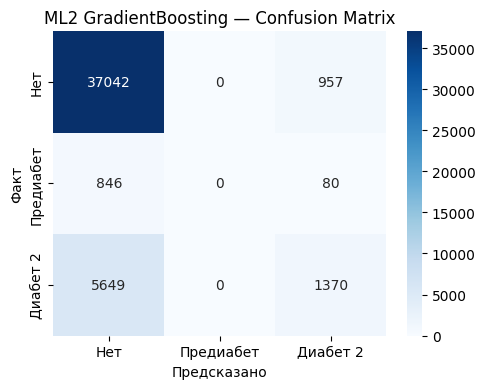

               precision    recall  f1-score   support

  Нет диабета       0.85      0.97      0.91     37999
    Предиабет       0.00      0.00      0.00       926
Диабет 2 типа       0.57      0.20      0.29      7019

     accuracy                           0.84     45944
    macro avg       0.47      0.39      0.40     45944
 weighted avg       0.79      0.84      0.80     45944

  📊 ML2 GradientBoosting — K-fold (mean ± std):
     accuracy              : 0.8352 ± 0.0014
     f1_macro              : 0.3979 ± 0.0024
     precision_macro       : 0.4699 ± 0.0051
     recall_macro          : 0.3887 ± 0.0017


In [26]:
model_gb, res_gb = train_or_load(
    key          = "ML2_GradientBoosting",
    model_factory= lambda: make_pipeline(GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3,
        subsample=1.0, random_state=42
    )),
    X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test,
    X_full=X, y_full=y, cv=skf
)
results_summary["ML2 GradientBoosting"] = res_gb

## 7. ML3 — CatBoostClassifier (продвинутый градиентный бустинг)

**Тип:** Продвинутый градиентный бустинг (Яндекс)  
**Описание:** Использует упорядоченный бустинг и симметричные деревья. Нативно поддерживает категориальные признаки.  
**Гиперпараметры:** подобраны в Lab4 с помощью GridSearchCV, F1-macro = 0.4222

📂 ML3 CatBoost: загружаем готовую модель (425.3 KB)
  📊 ML3 CatBoost — Hold-out метрики:
     Accuracy    : 0.8364
     Precision   : 0.4742
     Recall      : 0.3904
     F1-macro    : 0.4003


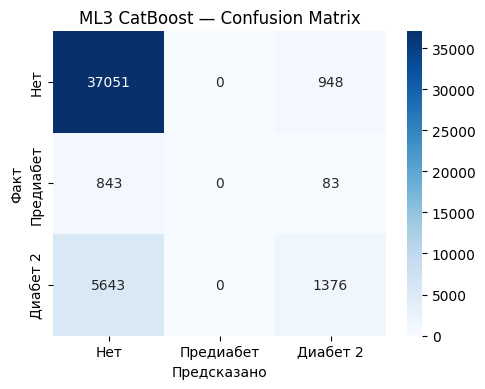

               precision    recall  f1-score   support

  Нет диабета       0.85      0.98      0.91     37999
    Предиабет       0.00      0.00      0.00       926
Диабет 2 типа       0.57      0.20      0.29      7019

     accuracy                           0.84     45944
    macro avg       0.47      0.39      0.40     45944
 weighted avg       0.79      0.84      0.80     45944

  📊 ML3 CatBoost — K-fold (mean ± std):
     accuracy              : 0.8356 ± 0.0011
     f1_macro              : 0.3986 ± 0.0023
     precision_macro       : 0.4713 ± 0.0043
     recall_macro          : 0.3892 ± 0.0016


In [27]:
from catboost import CatBoostClassifier

model_cb, res_cb = train_or_load(
    key          = "ML3_CatBoost",
    model_factory= lambda: make_pipeline(CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.1,
        verbose=0, random_state=42
    )),
    X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test,
    X_full=X, y_full=y, cv=skf
)
results_summary["ML3 CatBoost"] = res_cb

## 8. ML4 — BaggingClassifier (бэггинг)

**Тип:** Ансамблевая модель — бэггинг  
**Описание:** Обучает несколько деревьев на случайных bootstrap-подвыборках. Итоговое предсказание — большинство голосов.  
**Гиперпараметры:** подобраны в Lab4 с помощью GridSearchCV, F1-macro = 0.4019

📂 ML4 Bagging: загружаем готовую модель (93182.4 KB)
  📊 ML4 Bagging — Hold-out метрики:
     Accuracy    : 0.8122
     Precision   : 0.4210
     Recall      : 0.3873
     F1-macro    : 0.3934


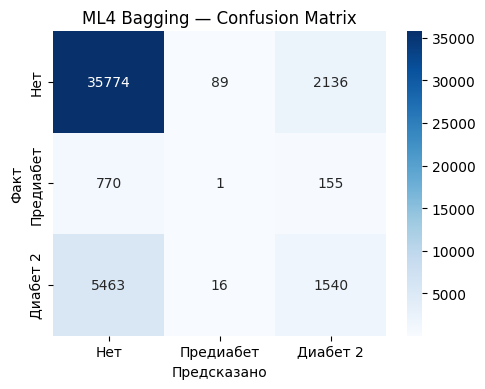

               precision    recall  f1-score   support

  Нет диабета       0.85      0.94      0.89     37999
    Предиабет       0.01      0.00      0.00       926
Диабет 2 типа       0.40      0.22      0.28      7019

     accuracy                           0.81     45944
    macro avg       0.42      0.39      0.39     45944
 weighted avg       0.77      0.81      0.78     45944

  📊 ML4 Bagging — K-fold (mean ± std):
     accuracy              : 0.8123 ± 0.0013
     f1_macro              : 0.3961 ± 0.0021
     precision_macro       : 0.4236 ± 0.0040
     recall_macro          : 0.3897 ± 0.0018


In [28]:
model_bag, res_bag = train_or_load(
    key          = "ML4_Bagging",
    model_factory= lambda: make_pipeline(BaggingClassifier(
        n_estimators=20, max_samples=1.0, max_features=1.0,
        bootstrap=True, random_state=42, n_jobs=2
    )),
    X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test,
    X_full=X, y_full=y, cv=skf
)
results_summary["ML4 Bagging"] = res_bag

## 9. ML5 — StackingClassifier (стэкинг)

**Тип:** Ансамблевая модель — стэкинг  
**Описание:** Базовые модели (DT + kNN + LR) генерируют предсказания, которые передаются в метаклассификатор LogisticRegression.  
**Гиперпараметры:** из Lab4, F1-macro = 0.4118

📂 ML5 Stacking: загружаем готовую модель (31597.7 KB)
  📊 ML5 Stacking — Hold-out метрики:
     Accuracy    : 0.8333
     Precision   : 0.4621
     Recall      : 0.3952
     F1-macro    : 0.4055


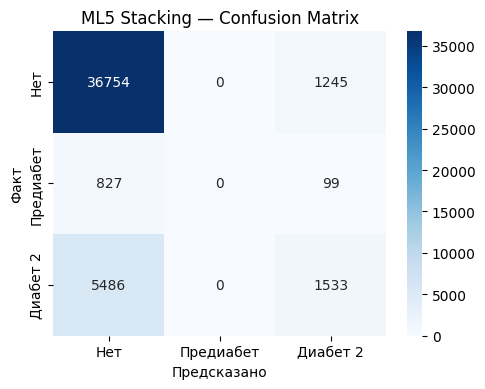

               precision    recall  f1-score   support

  Нет диабета       0.85      0.97      0.91     37999
    Предиабет       0.00      0.00      0.00       926
Диабет 2 типа       0.53      0.22      0.31      7019

     accuracy                           0.83     45944
    macro avg       0.46      0.40      0.41     45944
 weighted avg       0.79      0.83      0.80     45944

  📊 ML5 Stacking — K-fold (mean ± std):
     accuracy              : 0.8331 ± 0.0014
     f1_macro              : 0.4043 ± 0.0029
     precision_macro       : 0.4608 ± 0.0043
     recall_macro          : 0.3942 ± 0.0022


In [29]:
model_stack, res_stack = train_or_load(
    key          = "ML5_Stacking",
    model_factory= lambda: make_pipeline(
        StackingClassifier(
            estimators=[
                ("dt",  DecisionTreeClassifier(max_depth=5, random_state=42)),
                ("knn", KNeighborsClassifier(n_neighbors=7)),
                ("lr",  LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)),
            ],
            final_estimator=LogisticRegression(max_iter=5000, random_state=42),
            cv=3, n_jobs=2
        )
    ),
    X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test,
    X_full=X, y_full=y, cv=skf
)
results_summary["ML5 Stacking"] = res_stack

## 10. ML6 — MLPClassifier (нейронная сеть)

**Тип:** Глубокая полносвязная нейронная сеть  
**Описание:** MLP с гиперпараметрами из Lab7 (Sklearn+Hyperopt, F1-weighted=0.7920).  
**Ключевые условия Lab7, которые воспроизводятся здесь:**
1. Стратифицированный ресэмплинг обучающей выборки до **15 000 записей** (балансировка классов)
2. Отбор значимых признаков через **SelectKBest(f_classif)**
3. Архитектура и гиперпараметры: `hidden_layer_sizes=(128, 64)`, `activation=relu`, `solver=adam`

> ⚠️ Pipeline для инференса включает: `StandardScaler → SelectKBest → MLPClassifier`  
> Это важно — `app.py` должен подавать **все 21 признак**, Pipeline сам сделает отбор.

In [30]:
RGR_NN_PATH = MODEL_PATHS["ML6_NeuralNetwork"]

if os.path.exists(RGR_NN_PATH):
    print(f"📂 ML6_NeuralNetwork: загружаем готовую модель ({os.path.getsize(RGR_NN_PATH)/1024:.1f} KB)")
    model_nn = joblib.load(RGR_NN_PATH)
else:
    print("🔨 ML6_NeuralNetwork: обучаем по условиям Lab7...")

    MAX_SAMPLES = 15000
    X_tr_res, y_tr_res = resample(
        X_train, y_train,
        n_samples=MAX_SAMPLES,
        random_state=42,
        stratify=y_train
    )
    print(f"  После ресэмплинга: {X_tr_res.shape[0]} записей")
    print(f"  Распределение классов: {dict(pd.Series(y_tr_res).value_counts().sort_index())}")

    scaler_nn = StandardScaler()
    X_tr_scaled = scaler_nn.fit_transform(X_tr_res)
    X_ts_scaled = scaler_nn.transform(X_test)

    selector_nn = SelectKBest(f_classif, k="all").fit(X_tr_scaled, y_tr_res)
    sig_mask = selector_nn.pvalues_ < 0.05
    k_best = max(sig_mask.sum(), 5)
    selector_nn = SelectKBest(f_classif, k=k_best).fit(X_tr_scaled, y_tr_res)
    X_tr_sel = selector_nn.transform(X_tr_scaled)
    X_ts_sel = selector_nn.transform(X_ts_scaled)
    print(f"  Отобрано признаков: {k_best} из {X_train.shape[1]}")

    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42,
        verbose=True
    )
    mlp.fit(X_tr_sel, y_tr_res)

    model_nn = Pipeline([
        ("scaler",   scaler_nn),
        ("selector", selector_nn),
        ("model",    mlp),
    ])
    joblib.dump(model_nn, RGR_NN_PATH)
    print(f"💾 Сохранена: {RGR_NN_PATH}")


📂 ML6_NeuralNetwork: загружаем готовую модель (268.8 KB)


  📊 ML6 NeuralNetwork — Hold-out метрики:
     Accuracy    : 0.8250
     Precision   : 0.4398
     Recall      : 0.3936
     F1-macro    : 0.4017


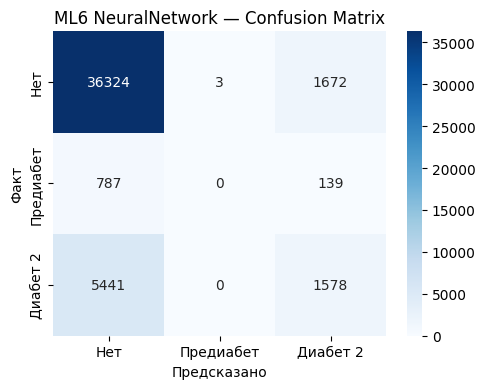

               precision    recall  f1-score   support

  Нет диабета       0.85      0.96      0.90     37999
    Предиабет       0.00      0.00      0.00       926
Диабет 2 типа       0.47      0.22      0.30      7019

     accuracy                           0.82     45944
    macro avg       0.44      0.39      0.40     45944
 weighted avg       0.78      0.82      0.79     45944



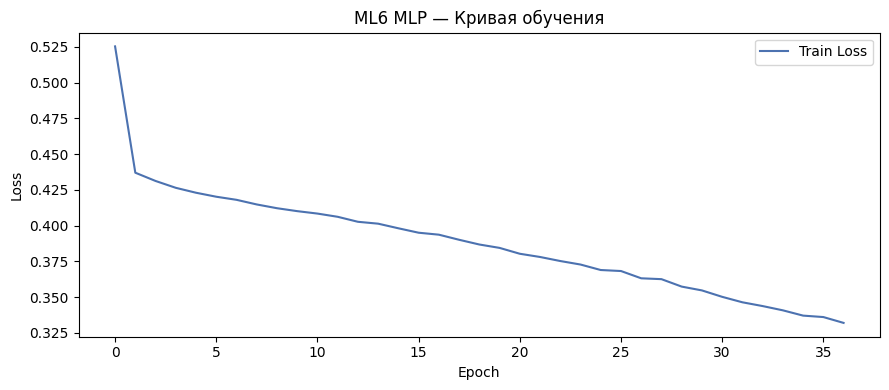

In [31]:
y_pred_nn = np.array(model_nn.predict(X_test)).flatten().astype(int)
res_nn = print_metrics("ML6 NeuralNetwork", y_test, y_pred_nn)
plot_confusion(y_test, y_pred_nn, "ML6 NeuralNetwork — Confusion Matrix")
print(classification_report(y_test, y_pred_nn,
      target_names=["Нет диабета", "Предиабет", "Диабет 2 типа"]))

try:
    mlp_step = model_nn["model"]
    if hasattr(mlp_step, "loss_curve_"):
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(mlp_step.loss_curve_, label="Train Loss", color="#4c72b0")
        ax.set(xlabel="Epoch", ylabel="Loss", title="ML6 MLP — Кривая обучения")
        ax.legend()
        plt.tight_layout()
        plt.show()
except Exception:
    pass

results_summary["ML6 NeuralNetwork"] = res_nn


## 11. Итоговая сравнительная таблица

ИТОГОВЫЕ МЕТРИКИ (Hold-out)


,Accuracy,Precision,Recall,F1-macro
Модель,,,,
ML1 DecisionTree,0.5738,0.4344,0.4764,0.3950
ML2 GradientBoosting,0.8361,0.4733,0.3900,0.3998
ML3 CatBoost,0.8364,0.4742,0.3904,0.4003
ML4 Bagging,0.8122,0.4210,0.3873,0.3934
ML5 Stacking,0.8333,0.4621,0.3952,0.4055
ML6 NeuralNetwork,0.8250,0.4398,0.3936,0.4017


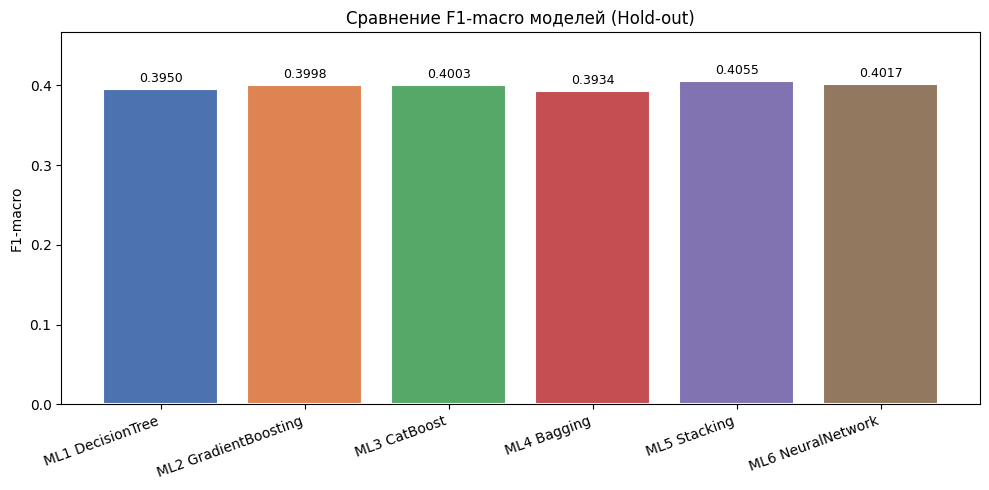

In [32]:
df_res = pd.DataFrame(results_summary).T.round(4)
df_res.index.name = "Модель"
print("=" * 60)
print("ИТОГОВЫЕ МЕТРИКИ (Hold-out)")
print("=" * 60)
display(df_res)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b2", "#937860"]
bars = ax.bar(df_res.index, df_res["F1-macro"], color=colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, df_res["F1-macro"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax.set(ylabel="F1-macro", title="Сравнение F1-macro моделей (Hold-out)")
ax.set_ylim(0, max(df_res["F1-macro"]) * 1.15)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 12. Финальная проверка сохранённых файлов

Убедимся, что все модели на месте и корректно загружаются.

In [33]:
print("Статус файлов моделей:")
print("-" * 60)
all_ok = True
for name, path in MODEL_PATHS.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "нет файла"
    icon   = "✅" if exists else "❌"
    print(f"  {icon} {name:<28} {size}")
    if not exists:
        all_ok = False
print("-" * 60)
print("✅ Все модели готовы!" if all_ok else "❌ Некоторые файлы отсутствуют")

Статус файлов моделей:
------------------------------------------------------------
  ✅ ML1_DecisionTree             162.8 KB
  ✅ ML2_GradientBoosting         393.5 KB
  ✅ ML3_CatBoost                 425.3 KB
  ✅ ML4_Bagging                  93182.4 KB
  ✅ ML5_Stacking                 31597.7 KB
  ✅ ML6_NeuralNetwork            268.8 KB
------------------------------------------------------------
✅ Все модели готовы!


In [34]:
sample   = X_test.sample(3, random_state=7)
true_lbl = y_test.loc[sample.index]
lbl_map  = {0: "Нет диабета", 1: "Предиабет", 2: "Диабет 2 типа"}

print("Тестовые предсказания на 3 случайных пациентах:")
print("-" * 60)
for name, path in MODEL_PATHS.items():
    if not os.path.exists(path):
        continue
    m = joblib.load(path)
    preds = np.array(m.predict(sample)).flatten().astype(int)
    row = "  ".join([
        f"{lbl_map[p]} ({"✅" if p == t else "❌"} факт: {lbl_map[t]})"
        for p, t in zip(preds, true_lbl.values)
    ])
    print(f"  {name:<28} {row}")

Тестовые предсказания на 3 случайных пациентах:
------------------------------------------------------------
  ML1_DecisionTree             Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)
  ML2_GradientBoosting         Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)


  ML3_CatBoost                 Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)
  ML4_Bagging                  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)
  ML5_Stacking                 Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)
  ML6_NeuralNetwork            Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)


In [39]:
app_content = f"""
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

st.set_page_config(
    page_title="DiabetIQ — ML Inference Dashboard",
    page_icon="🔬",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown(\"\"\"
<style>
@import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@300;400;600;700&family=Syne:wght@400;600;700;800&display=swap');

/* ── BASE ── */
*, *::before, *::after {{ box-sizing: border-box; }}

html, body, .stApp {{
    background-color: #0a0e17 !important;
    color: #c8d6e5 !important;
    font-family: 'Syne', sans-serif !important;
}}

/* ── SIDEBAR ── */
[data-testid="stSidebar"] {{
    background: #0d1220 !important;
    border-right: 1px solid #1e2d45 !important;
}}
[data-testid="stSidebar"] * {{ color: #c8d6e5 !important; }}
[data-testid="stSidebar"] .stRadio label {{
    font-family: 'JetBrains Mono', monospace !important;
    font-size: 0.78rem !important;
    letter-spacing: 0.05em !important;
}}

/* ── SIDEBAR LOGO ── */
.sidebar-logo {{
    font-family: 'Syne', sans-serif;
    font-weight: 800;
    font-size: 1.6rem;
    letter-spacing: -0.02em;
    color: #e8f4fd !important;
    line-height: 1;
    padding: 0.5rem 0 0.2rem;
}}
.sidebar-logo span {{ color: #3dd6f5 !important; }}
.sidebar-tagline {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.65rem;
    color: #4a6580 !important;
    letter-spacing: 0.12em;
    text-transform: uppercase;
    margin-top: 0.1rem;
}}

/* ── MAIN HEADER ── */
.page-header {{
    display: flex;
    align-items: baseline;
    gap: 1rem;
    margin-bottom: 0.3rem;
    padding-bottom: 1rem;
    border-bottom: 1px solid #1e2d45;
}}
.page-title {{
    font-family: 'Syne', sans-serif;
    font-weight: 800;
    font-size: 2rem;
    color: #e8f4fd;
    letter-spacing: -0.03em;
    line-height: 1;
}}
.page-badge {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.65rem;
    letter-spacing: 0.12em;
    text-transform: uppercase;
    color: #3dd6f5;
    background: rgba(61,214,245,0.08);
    border: 1px solid rgba(61,214,245,0.25);
    padding: 0.25rem 0.6rem;
    border-radius: 2px;
}}

/* ── DATA CARD ── */
.dcard {{
    background: #0f1826;
    border: 1px solid #1e2d45;
    border-radius: 4px;
    padding: 1.2rem 1.4rem;
    margin-bottom: 0.8rem;
    position: relative;
}}
.dcard::before {{
    content: '';
    position: absolute;
    top: 0; left: 0;
    width: 3px; height: 100%;
    background: #3dd6f5;
    border-radius: 4px 0 0 4px;
}}
.dcard-label {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.65rem;
    text-transform: uppercase;
    letter-spacing: 0.12em;
    color: #4a6580;
    margin-bottom: 0.4rem;
}}
.dcard-value {{
    font-family: 'Syne', sans-serif;
    font-weight: 700;
    font-size: 1.05rem;
    color: #e8f4fd;
    line-height: 1.3;
}}

/* ── STAT BLOCK ── */
.stat-row {{
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 0.8rem;
    margin: 1rem 0;
}}
.stat-block {{
    background: #0f1826;
    border: 1px solid #1e2d45;
    border-top: 2px solid #3dd6f5;
    padding: 1rem;
    text-align: center;
    border-radius: 0 0 4px 4px;
}}
.stat-num {{
    font-family: 'Syne', sans-serif;
    font-weight: 800;
    font-size: 1.8rem;
    color: #3dd6f5;
    letter-spacing: -0.04em;
    line-height: 1;
}}
.stat-lbl {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.6rem;
    text-transform: uppercase;
    letter-spacing: 0.1em;
    color: #4a6580;
    margin-top: 0.3rem;
}}

/* ── RESULT CARDS ── */
.result-card {{
    border: 1px solid #1e2d45;
    border-radius: 4px;
    padding: 1rem 1.2rem;
    margin-bottom: 0.6rem;
    position: relative;
    overflow: hidden;
}}
.result-card::after {{
    content: '';
    position: absolute;
    top: 0; right: 0;
    width: 40%; height: 100%;
    opacity: 0.03;
    border-radius: 0 4px 4px 0;
}}
.result-ok   {{ background: #081510; border-color: #1a4a33; }}
.result-ok::after   {{ background: #00c851; }}
.result-warn {{ background: #150e05; border-color: #4a3010; }}
.result-warn::after {{ background: #ff9800; }}
.result-bad  {{ background: #150508; border-color: #4a1020; }}
.result-bad::after  {{ background: #ff1744; }}

.result-model {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.65rem;
    text-transform: uppercase;
    letter-spacing: 0.1em;
    color: #4a6580;
    margin-bottom: 0.3rem;
}}
.result-label-ok   {{ font-family:'Syne',sans-serif; font-weight:700; font-size:1rem; color:#00c851; }}
.result-label-warn {{ font-family:'Syne',sans-serif; font-weight:700; font-size:1rem; color:#ff9800; }}
.result-label-bad  {{ font-family:'Syne',sans-serif; font-weight:700; font-size:1rem; color:#ff1744; }}
.result-f1 {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.7rem;
    color: #4a6580;
    margin-top: 0.2rem;
}}

/* ── TECH TAG ── */
.tech-grid {{ display:flex; flex-wrap:wrap; gap:0.5rem; margin:0.8rem 0; }}
.tech-tag {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.7rem;
    letter-spacing: 0.06em;
    color: #3dd6f5;
    background: rgba(61,214,245,0.06);
    border: 1px solid rgba(61,214,245,0.2);
    padding: 0.3rem 0.7rem;
    border-radius: 2px;
    white-space: nowrap;
}}

/* ── MODEL CHIP ── */
.model-row {{
    display: flex;
    align-items: center;
    justify-content: space-between;
    padding: 0.6rem 0.8rem;
    border-bottom: 1px solid #1e2d45;
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.72rem;
}}
.model-row:last-child {{ border-bottom: none; }}
.model-type {{ color: #4a6580; font-size: 0.62rem; text-transform: uppercase; letter-spacing: 0.1em; }}
.model-name {{ color: #c8d6e5; }}
.model-f1   {{ color: #3dd6f5; font-weight: 600; }}

/* ── DIVIDER ── */
.sec-div {{
    border: none;
    border-top: 1px solid #1e2d45;
    margin: 1.5rem 0;
}}

/* ── STREAMLIT OVERRIDES ── */
.stButton > button {{
    background: #3dd6f5 !important;
    color: #0a0e17 !important;
    border: none !important;
    border-radius: 3px !important;
    font-family: 'Syne', sans-serif !important;
    font-weight: 700 !important;
    font-size: 0.9rem !important;
    letter-spacing: 0.03em !important;
    padding: 0.6rem 2rem !important;
    transition: opacity 0.15s !important;
}}
.stButton > button:hover {{ opacity: 0.85 !important; }}

.stSelectbox label, .stSlider label, .stMultiSelect label,
.stNumberInput label, .stFileUploader label {{
    font-family: 'JetBrains Mono', monospace !important;
    font-size: 0.72rem !important;
    text-transform: uppercase !important;
    letter-spacing: 0.08em !important;
    color: #4a6580 !important;
}}
.stSelectbox > div > div,
.stMultiSelect > div > div {{
    background: #0f1826 !important;
    border-color: #1e2d45 !important;
    border-radius: 3px !important;
    color: #c8d6e5 !important;
}}
.stSlider [data-testid="stTickBarMin"],
.stSlider [data-testid="stTickBarMax"] {{
    font-family: 'JetBrains Mono', monospace !important;
    color: #4a6580 !important;
}}
[data-testid="stMetric"] {{
    background: #0f1826 !important;
    border: 1px solid #1e2d45 !important;
    border-radius: 3px !important;
    padding: 0.8rem !important;
}}
[data-testid="stMetricLabel"] {{
    font-family: 'JetBrains Mono', monospace !important;
    font-size: 0.65rem !important;
    text-transform: uppercase !important;
    letter-spacing: 0.1em !important;
    color: #4a6580 !important;
}}
[data-testid="stMetricValue"] {{
    font-family: 'Syne', sans-serif !important;
    font-weight: 800 !important;
    color: #3dd6f5 !important;
}}
.stTabs [data-baseweb="tab"] {{
    font-family: 'JetBrains Mono', monospace !important;
    font-size: 0.72rem !important;
    text-transform: uppercase !important;
    letter-spacing: 0.08em !important;
    color: #4a6580 !important;
    background: transparent !important;
}}
.stTabs [aria-selected="true"] {{
    color: #3dd6f5 !important;
    border-bottom: 2px solid #3dd6f5 !important;
}}
.stDataFrame {{ border: 1px solid #1e2d45 !important; border-radius: 3px !important; }}
.stExpander {{ border: 1px solid #1e2d45 !important; background: #0f1826 !important; border-radius: 3px !important; }}
.stExpander summary {{ font-family: 'JetBrains Mono', monospace !important; font-size: 0.75rem !important; color: #c8d6e5 !important; }}

/* scrollbar */
::-webkit-scrollbar {{ width: 5px; height: 5px; }}
::-webkit-scrollbar-track {{ background: #0a0e17; }}
::-webkit-scrollbar-thumb {{ background: #1e2d45; border-radius: 3px; }}
</style>
\"\"\", unsafe_allow_html=True)

plt.rcParams.update({{
    'figure.facecolor':  '#0f1826',
    'axes.facecolor':    '#0f1826',
    'axes.edgecolor':    '#1e2d45',
    'axes.labelcolor':   '#7a92a8',
    'axes.titlecolor':   '#c8d6e5',
    'xtick.color':       '#4a6580',
    'ytick.color':       '#4a6580',
    'text.color':        '#c8d6e5',
    'grid.color':        '#1e2d45',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'monospace',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        120,
}})

PALETTE = {{0: '#00c851', 1: '#ff9800', 2: '#ff1744'}}
PALETTE_ALPHA = {{0: '#00c85130', 1: '#ff980030', 2: '#ff174430'}}

FEATURE_NAMES = [
    'HighBP','HighChol','CholCheck','BMI','Smoker','Stroke',
    'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
    'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','GenHlth',
    'MentHlth','PhysHlth','DiffWalk','Sex','Age','Education','Income'
]

FEATURE_DESCRIPTIONS = {{
    'HighBP':               ('Высокое АД',                    'бин. (0/1)'),
    'HighChol':             ('Высокий холестерин',             'бин. (0/1)'),
    'CholCheck':            ('Проверка холестерина ≤5 лет',    'бин. (0/1)'),
    'BMI':                  ('Индекс массы тела',              'числовой'),
    'Smoker':               ('Курение ≥100 сигарет',           'бин. (0/1)'),
    'Stroke':               ('Инсульт в анамнезе',             'бин. (0/1)'),
    'HeartDiseaseorAttack': ('ИБС / инфаркт',                 'бин. (0/1)'),
    'PhysActivity':         ('Физактивность (30 дней)',        'бин. (0/1)'),
    'Fruits':               ('Фрукты ≥1/день',                'бин. (0/1)'),
    'Veggies':              ('Овощи ≥1/день',                  'бин. (0/1)'),
    'HvyAlcoholConsump':    ('Злоупотр. алкоголем',           'бин. (0/1)'),
    'AnyHealthcare':        ('Медстраховка',                   'бин. (0/1)'),
    'NoDocbcCost':          ('Не мог позволить врача',         'бин. (0/1)'),
    'GenHlth':              ('Общее здоровье',                 'порядк. 1–5'),
    'MentHlth':             ('Дней плохого псих. здоровья',   'числ. 0–30'),
    'PhysHlth':             ('Дней плохого физ. здоровья',    'числ. 0–30'),
    'DiffWalk':             ('Трудности с ходьбой',            'бин. (0/1)'),
    'Sex':                  ('Пол',                            '0=жен, 1=муж'),
    'Age':                  ('Возрастная группа',              'порядк. 1–13'),
    'Education':            ('Образование',                    'порядк. 1–6'),
    'Income':               ('Доход',                          'порядк. 1–8'),
}}

MODEL_INFO = {{
    'DecisionTree':     {{'path': 'models/dt_classifier_model.pkl',    'f1': {res_dt['F1-macro']:.4f}, 'label': 'Decision Tree',      'type': 'ML1 / Classic'}},
    'GradientBoosting': {{'path': 'models/gb_classifier_model.pkl',    'f1': {res_gb['F1-macro']:.4f}, 'label': 'Gradient Boosting',  'type': 'ML2 / Boosting'}},
    'CatBoost':         {{'path': 'models/cb_classifier_model.pkl',    'f1': {res_cb['F1-macro']:.4f}, 'label': 'CatBoost',           'type': 'ML3 / Adv. Boosting'}},
    'Bagging':          {{'path': 'models/bag_classifier_model.pkl',   'f1': {res_bag['F1-macro']:.4f}, 'label': 'Bagging',            'type': 'ML4 / Bagging'}},
    'Stacking':         {{'path': 'models/stack_classifier_model.pkl', 'f1': {res_stack['F1-macro']:.4f}, 'label': 'Stacking',           'type': 'ML5 / Stacking'}},
    'NeuralNetwork':    {{'path': 'models/nn_classifier_model.pkl',    'f1': {res_nn['F1-macro']:.4f}, 'label': 'MLP Neural Net',     'type': 'ML6 / Deep'}},
}}

CLASS_LABELS = {{0: 'Диабет не выявлен', 1: 'Предиабет', 2: 'Диабет 2 типа'}}
CLASS_SHORT   = {{0: 'НОРМА', 1: 'ПРЕДИАБЕТ', 2: 'ДИАБЕТ II'}}
CLASS_CSS     = {{0: 'result-ok', 1: 'result-warn', 2: 'result-bad'}}
CLASS_LCSS    = {{0: 'result-label-ok', 1: 'result-label-warn', 2: 'result-label-bad'}}
CLASS_EMOJI   = {{0: '●', 1: '▲', 2: '■'}}

AGE_GROUPS = {{
    1:'18–24',2:'25–29',3:'30–34',4:'35–39',5:'40–44',
    6:'45–49',7:'50–54',8:'55–59',9:'60–64',10:'65–69',
    11:'70–74',12:'75–79',13:'80+',
}}

@st.cache_resource
def load_model(path):
    if not os.path.exists(path):
        return None
    return joblib.load(path)

def predict(model_key, model_obj, X):
    if isinstance(model_obj, dict) and 'scaler' in model_obj:
        X_sc = model_obj['scaler'].transform(X)
        preds = model_obj['model'].predict(X_sc)
    else:
        preds = model_obj.predict(X)
    preds = np.array(preds)
    if preds.ndim > 1:
        preds = preds.flatten()
    return preds.astype(int)

@st.cache_data
def load_dataset():
    for p in ['filtered_diabetes_health_indicators.csv',
              'datasets/filtered_diabetes_health_indicators.csv',
              'data/filtered_diabetes_health_indicators.csv']:
        if os.path.exists(p):
            return pd.read_csv(p)
    return None

def _do_prediction(X_input, selected_models, manual=False):
    if not selected_models:
        st.warning("Выберите хотя бы одну модель.")
        return

    st.markdown('<hr class="sec-div">', unsafe_allow_html=True)
    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin-bottom:1rem;">Результаты инференса</div>', unsafe_allow_html=True)

    results = []
    for key in selected_models:
        info = MODEL_INFO[key]
        model = load_model(info['path'])
        if model is None:
            results.append({{'key': key, 'info': info, 'preds': None, 'error': 'Модель не найдена'}})
            continue
        try:
            preds = predict(key, model, X_input)
            results.append({{'key': key, 'info': info, 'preds': preds, 'error': None}})
        except Exception as e:
            results.append({{'key': key, 'info': info, 'preds': None, 'error': str(e)}})

    if manual and len(X_input) == 1:
        cols = st.columns(min(len(results), 3), gap="small")
        for i, res in enumerate(results):
            with cols[i % len(cols)]:
                if res['error']:
                    st.markdown(f\"\"\"
                    <div class="result-card" style="border-color:#2a3d55;">
                        <div class="result-model">{{res['info']['type']}}</div>
                        <div style="font-family:JetBrains Mono,monospace;font-size:0.72rem;color:#4a6580;">{{res['error']}}</div>
                    </div>\"\"\", unsafe_allow_html=True)
                else:
                    cls = int(res['preds'][0])
                    css = CLASS_CSS[cls]; lcss = CLASS_LCSS[cls]
                    sym = CLASS_EMOJI[cls]
                    st.markdown(f\"\"\"
                    <div class="result-card {{css}}">
                        <div class="result-model">{{res['info']['type']}} · {{res['info']['label']}}</div>
                        <div class="{{lcss}}">{{sym}} {{CLASS_SHORT[cls]}}</div>
                        <div style="font-family:Syne,sans-serif;font-size:0.8rem;color:#c8d6e5;margin-top:0.3rem;">{{CLASS_LABELS[cls]}}</div>
                        <div class="result-f1">F1-macro = {{res['info']['f1']:.4f}}</div>
                    </div>\"\"\", unsafe_allow_html=True)

        valid = [r for r in results if r['preds'] is not None]
        if len(valid) > 1:
            st.markdown('<hr class="sec-div">', unsafe_allow_html=True)
            model_names  = [r['info']['label'] for r in valid]
            f1_scores    = [r['info']['f1']     for r in valid]
            pred_classes = [int(r['preds'][0])  for r in valid]

            fig, ax = plt.subplots(figsize=(10, 3.5))
            colors = [PALETTE[p] for p in pred_classes]
            bars = ax.barh(model_names, f1_scores, color=colors, alpha=0.8,
                           height=0.5, edgecolor='none')
            ax.set_xlim(0, 1.05)
            ax.set_xlabel("F1-macro (test set)")
            ax.set_title("Сравнение качества моделей (цвет = предсказанный класс)", fontsize=9)
            ax.xaxis.grid(True); ax.set_axisbelow(True)
            for bar, f1 in zip(bars, f1_scores):
                ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                        f'{{f1:.4f}}', va='center', fontsize=8, color='#c8d6e5')
            handles = [mpatches.Patch(facecolor=PALETTE[c], label=CLASS_SHORT[c]) for c in [0,1,2]]
            ax.legend(handles=handles, loc='lower right', frameon=False, labelcolor='#c8d6e5', fontsize=8)
            plt.tight_layout()
            st.pyplot(fig, use_container_width=True)
            plt.close()
    else:
        rows = []
        for res in results:
            if res['error']:
                rows.append({{'Модель': res['info']['label'], 'Запись': '—', 'Предсказание': res['error'], 'F1': res['info']['f1']}})
            else:
                for j, p in enumerate(res['preds']):
                    rows.append({{'Модель': res['info']['label'], 'Запись': j+1,
                                 'Предсказание': f"{{CLASS_EMOJI[p]}} {{CLASS_LABELS[p]}}", 'F1': res['info']['f1']}})
        if rows:
            st.dataframe(pd.DataFrame(rows), use_container_width=True, hide_index=True)

with st.sidebar:
    st.markdown('<div class="sidebar-logo">Diabet<span>IQ</span></div>', unsafe_allow_html=True)
    st.markdown('<div class="sidebar-tagline">ML Inference Dashboard</div>', unsafe_allow_html=True)
    st.markdown('<hr class="sec-div">', unsafe_allow_html=True)

    PAGE = st.radio("nav", [
        "01 / Разработчик",
        "02 / Датасет",
        "03 / Визуализации",
        "04 / Предсказание",
    ], label_visibility="collapsed")

    st.markdown('<hr class="sec-div">', unsafe_allow_html=True)
    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin-bottom:0.5rem;">Модели</div>', unsafe_allow_html=True)

    model_table = "".join([
        f'<div class="model-row">'
        f'<span><span class="model-type">{{info["type"]}}</span><br>'
        f'<span class="model-name">{{info["label"]}}</span></span>'
        f'<span class="model-f1">F1 {{info["f1"]:.3f}}</span>'
        f'</div>'
        for info in MODEL_INFO.values()
    ])
    st.markdown(f'<div style="background:#0a0e17;border:1px solid #1e2d45;border-radius:3px;">{{model_table}}</div>', unsafe_allow_html=True)

    st.markdown('<hr class="sec-div">', unsafe_allow_html=True)
    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.6rem;color:#2a3d55;text-align:center;">РГР · Машинное обучение<br>и большие данные</div>', unsafe_allow_html=True)

if PAGE == "01 / Разработчик":
    st.markdown(\"\"\"
    <div class="page-header">
        <div class="page-title">Разработчик</div>
        <div class="page-badge">Profile</div>
    </div>\"\"\", unsafe_allow_html=True)

    col_photo, col_info = st.columns([1, 2], gap="large")

    with col_photo:
        photo_found = False
        for pp in ['photo.jpg','Photo.jpg','photo.png','Photo.png']:
            if os.path.exists(pp):
                st.image(pp, use_container_width=True)
                photo_found = True
                break
        if not photo_found:
            st.markdown(\"\"\"
            <div style="aspect-ratio:3/4;background:#0f1826;border:1px solid #1e2d45;
                        border-radius:3px;display:flex;align-items:center;
                        justify-content:center;font-size:4rem;color:#1e2d45;">
                ◈
            </div>\"\"\", unsafe_allow_html=True)

    with col_info:
        st.markdown(\"\"\"
        <div class="dcard">
            <div class="dcard-label">ФИО</div>
            <div class="dcard-value">Рау Алексей Евгеньевич</div>
        </div>
        <div class="dcard">
            <div class="dcard-label">Учебная группа</div>
            <div class="dcard-value">ФИТ-231</div>
        </div>
        <div class="dcard">
            <div class="dcard-label">Дисциплина</div>
            <div class="dcard-value">Машинное обучение и большие данные</div>
        </div>
        <div class="dcard">
            <div class="dcard-label">Тема РГР</div>
            <div class="dcard-value" style="font-size:0.95rem;line-height:1.5;">
                Разработка Web-приложения (дашборда) для инференса моделей ML<br>
                и анализа данных
            </div>
        </div>
        \"\"\", unsafe_allow_html=True)

    st.markdown('<hr class="sec-div">', unsafe_allow_html=True)
    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin-bottom:0.8rem;">Стек технологий</div>', unsafe_allow_html=True)

    st.markdown(\"\"\"
    <div class="tech-grid">
        <span class="tech-tag">Python 3.11</span>
        <span class="tech-tag">Scikit-learn</span>
        <span class="tech-tag">CatBoost</span>
        <span class="tech-tag">Streamlit</span>
        <span class="tech-tag">Pandas</span>
        <span class="tech-tag">NumPy</span>
        <span class="tech-tag">Matplotlib</span>
        <span class="tech-tag">Seaborn</span>
        <span class="tech-tag">Joblib</span>
    </div>
    \"\"\", unsafe_allow_html=True)

    st.markdown('<hr class="sec-div">', unsafe_allow_html=True)
    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin-bottom:0.8rem;">Датасет</div>', unsafe_allow_html=True)
    st.markdown(\"\"\"
    <div class="dcard">
        <div class="dcard-label">Источник</div>
        <div class="dcard-value" style="font-size:0.92rem;">
            Diabetes Health Indicators — CDC BRFSS 2015<br>
            <span style="font-family:JetBrains Mono,monospace;font-size:0.72rem;color:#4a6580;">
            229 718 записей · 22 признака · 3 класса
            </span>
        </div>
    </div>
    \"\"\", unsafe_allow_html=True)

elif PAGE == "02 / Датасет":
    st.markdown(\"\"\"
    <div class="page-header">
        <div class="page-title">Датасет</div>
        <div class="page-badge">EDA</div>
    </div>\"\"\", unsafe_allow_html=True)

    st.markdown(\"\"\"
    <div class="dcard" style="margin-bottom:1.4rem;">
        <div class="dcard-label">Описание предметной области</div>
        <div class="dcard-value" style="font-weight:400;font-size:0.92rem;line-height:1.7;color:#c8d6e5;">
            Diabetes Health Indicators Dataset основан на ежегодном телефонном опросе BRFSS (Behavioral
            Risk Factor Surveillance System), проводимом CDC в США. Каждая запись — один респондент,
            который сообщил о состоянии своего здоровья, образе жизни и социально-демографических
            характеристиках. Целевая переменная <code style="color:#3dd6f5;background:#0a0e17;padding:1px 5px;border-radius:2px;">Diabetes_012</code>
            кодирует три состояния: отсутствие диабета, предиабет и диабет 2 типа.
        </div>
    </div>
    \"\"\", unsafe_allow_html=True)

    c1, c2, c3 = st.columns(3)
    for col, cls, label, cnt, pct in [
        (c1, 0, 'НОРМА',     '189 994', '82.7%'),
        (c2, 1, 'ПРЕДИАБЕТ', '4 629',   '2.0%'),
        (c3, 2, 'ДИАБЕТ II', '35 095',  '15.3%'),
    ]:
        clr = PALETTE[cls]
        col.markdown(f\"\"\"
        <div style="background:#0f1826;border:1px solid #1e2d45;border-top:2px solid {{clr}};
                    border-radius:0 0 4px 4px;padding:1.2rem;text-align:center;">
            <div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;
                        text-transform:uppercase;letter-spacing:0.12em;color:{{clr}};margin-bottom:0.4rem;">
                Класс {{cls}}
            </div>
            <div style="font-family:JetBrains Mono,monospace;font-weight:600;font-size:1.45rem;
                        color:#e8f4fd;letter-spacing:0.02em;">{{cnt}}</div>
            <div style="font-family:JetBrains Mono,monospace;font-size:0.68rem;color:#4a6580;margin-top:0.2rem;">{{label}} · {{pct}}</div>
        </div>
        \"\"\", unsafe_allow_html=True)

    st.markdown('<hr class="sec-div">', unsafe_allow_html=True)
    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin-bottom:0.8rem;">Признаки датасета</div>', unsafe_allow_html=True)

    rows = [{{'Признак': f, 'Описание': d, 'Тип': t}} for f,(d,t) in FEATURE_DESCRIPTIONS.items()]
    st.dataframe(pd.DataFrame(rows), use_container_width=True, hide_index=True, height=400)

    st.markdown('<hr class="sec-div">', unsafe_allow_html=True)
    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin-bottom:0.8rem;">Предобработка данных</div>', unsafe_allow_html=True)

    steps = [
        ("01", "Загрузка",        "CSV · 229 718 строк × 22 столбца"),
        ("02", "Пропуски",        "Отсутствуют — датасет предочищен"),
        ("03", "Разбиение",       "Hold-out 80/20 · stratify=y · random_state=42"),
        ("04", "Масштабирование", "StandardScaler · fit только на train"),
        ("05", "Балансировка",    "StratifiedKFold(n_splits=5) для оценки"),
        ("06", "ML6 — спецшаги", "Resample 15k · SelectKBest(f_classif)"),
    ]
    for num, title, desc in steps:
        st.markdown(f\"\"\"
        <div style="display:flex;align-items:flex-start;gap:1rem;padding:0.7rem 0;border-bottom:1px solid #1e2d45;">
            <div style="font-family:JetBrains Mono,monospace;font-size:0.7rem;
                        color:#3dd6f5;min-width:2rem;padding-top:0.1rem;">{{num}}</div>
            <div>
                <div style="font-family:Syne,sans-serif;font-weight:600;font-size:0.88rem;color:#e8f4fd;">{{title}}</div>
                <div style="font-family:JetBrains Mono,monospace;font-size:0.68rem;color:#4a6580;margin-top:0.15rem;">{{desc}}</div>
            </div>
        </div>
        \"\"\", unsafe_allow_html=True)

    st.markdown('<hr class="sec-div">', unsafe_allow_html=True)

    df = load_dataset()
    if df is not None:
        st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin-bottom:0.8rem;">Live EDA</div>', unsafe_allow_html=True)
        m1,m2,m3,m4 = st.columns(4)
        m1.metric("Строк",       f"{{df.shape[0]:,}}")
        m2.metric("Признаков",   df.shape[1])
        m3.metric("Пропусков",   int(df.isnull().sum().sum()))
        m4.metric("Дубликатов",  int(df.duplicated().sum()))
        with st.expander("Первые 10 строк"):
            st.dataframe(df.head(10), use_container_width=True)
        with st.expander("Сводная статистика"):
            st.dataframe(df.describe().round(2), use_container_width=True)
    else:
        st.info("Положите `filtered_diabetes_health_indicators.csv` рядом с app.py для Live EDA.")

elif PAGE == "03 / Визуализации":
    st.markdown(\"\"\"
    <div class="page-header">
        <div class="page-title">Визуализации</div>
        <div class="page-badge">Analytics</div>
    </div>\"\"\", unsafe_allow_html=True)

    df = load_dataset()
    if df is None:
        st.info("📂 Демо-режим: синтетические данные (датасет не найден)")
        rng = np.random.default_rng(42)
        n = 2000
        df = pd.DataFrame({{
            'BMI':     rng.normal(28,6,n).clip(12,70),
            'Age':     rng.integers(1,14,n),
            'GenHlth': rng.integers(1,6,n),
            'MentHlth':rng.integers(0,31,n),
            'PhysHlth':rng.integers(0,31,n),
            'HighBP':  rng.integers(0,2,n),
            'HighChol':rng.integers(0,2,n),
            'Smoker':  rng.integers(0,2,n),
            'Stroke':  rng.integers(0,2,n),
            'HeartDiseaseorAttack': rng.integers(0,2,n),
            'PhysActivity': rng.integers(0,2,n),
            'DiffWalk':rng.integers(0,2,n),
            'Diabetes_012': rng.choice([0,1,2],n,p=[0.83,0.02,0.15]),
        }})

    target = 'Diabetes_012'
    num_cols = [c for c in ['BMI','Age','GenHlth','MentHlth','PhysHlth'] if c in df.columns]
    bin_cols = [c for c in ['HighBP','HighChol','Smoker','Stroke','HeartDiseaseorAttack','PhysActivity','DiffWalk'] if c in df.columns]

    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin:1rem 0 0.6rem;">01 / Распределение целевой переменной</div>', unsafe_allow_html=True)
    counts = df[target].value_counts().sort_index()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

    bars = ax1.bar([CLASS_SHORT[i] for i in counts.index],
                   counts.values,
                   color=[PALETTE[i] for i in counts.index],
                   width=0.5, edgecolor='none')
    ax1.set_ylabel("Количество записей")
    ax1.set_title("Частота классов")
    ax1.yaxis.grid(True); ax1.set_axisbelow(True)
    for b, v in zip(bars, counts.values):
        ax1.text(b.get_x()+b.get_width()/2, v+200, f'{{v:,}}',
                 ha='center', va='bottom', fontsize=7, color='#c8d6e5')

    wedges, texts, autotexts = ax2.pie(
        counts.values,
        colors=[PALETTE[i] for i in counts.index],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={{'edgecolor':'#0f1826','linewidth':2}},
        pctdistance=0.7
    )
    for at in autotexts: at.set_fontsize(8); at.set_color('#0a0e17')
    ax2.legend([CLASS_SHORT[i] for i in counts.index], loc='lower center',
               bbox_to_anchor=(0.5,-0.12), ncol=3, fontsize=7,
               frameon=False, labelcolor='#c8d6e5')
    ax2.set_title("Доля классов")

    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close()

    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin:1.5rem 0 0.6rem;">02 / Box-plot числовых признаков по классам</div>', unsafe_allow_html=True)
    if num_cols:
        fig, axes = plt.subplots(1, len(num_cols), figsize=(3.5*len(num_cols), 4))
        if len(num_cols) == 1: axes = [axes]
        for ax, col in zip(axes, num_cols):
            data = [df[df[target]==cls][col].dropna() for cls in [0,1,2] if cls in df[target].values]
            bp = ax.boxplot(data, patch_artist=True, notch=False,
                            medianprops={{'color':'#e8f4fd','linewidth':2}},
                            whiskerprops={{'color':'#2a3d55'}},
                            capprops={{'color':'#2a3d55'}},
                            flierprops={{'marker':'o','markersize':2,'alpha':0.3,'color':'#4a6580'}})
            for patch, cls in zip(bp['boxes'], [0,1,2]):
                patch.set_facecolor(PALETTE[cls])
                patch.set_alpha(0.7)
                patch.set_edgecolor('none')
            ax.set_title(col, fontsize=9)
            ax.set_xticks([1,2,3])
            ax.set_xticklabels(['НОРМА','ПРЕД.','ДИАБ.'], fontsize=7)
            ax.yaxis.grid(True); ax.set_axisbelow(True)
        plt.suptitle("Числовые признаки по классам диабета", y=1.02, fontsize=9)
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        plt.close()

    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin:1.5rem 0 0.6rem;">03 / Матрица корреляций</div>', unsafe_allow_html=True)
    corr_cols = [c for c in FEATURE_NAMES if c in df.columns] + [target]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(13, 9))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
                center=0, ax=ax, annot_kws={{'size':6.5}},
                linewidths=0.3, linecolor='#0a0e17',
                cbar_kws={{'shrink':0.6}})
    ax.set_title("Матрица корреляций (нижний треугольник)", fontsize=10, pad=12)
    ax.tick_params(labelsize=7)
    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close()

    st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin:1.5rem 0 0.6rem;">04 / Факторы риска по классам (стековые диаграммы)</div>', unsafe_allow_html=True)
    if bin_cols:
        fig, axes = plt.subplots(2, 4, figsize=(16, 7))
        axes = axes.flatten()
        for i, col in enumerate(bin_cols[:8]):
            ct = df.groupby([col, target]).size().unstack(fill_value=0)
            ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
            bottom = np.zeros(len(ct_pct))
            for cls in [0,1,2]:
                if cls in ct_pct.columns:
                    axes[i].bar(ct_pct.index, ct_pct[cls],
                                bottom=bottom,
                                color=PALETTE[cls], alpha=0.85, edgecolor='none')
                    bottom += ct_pct[cls].values
            axes[i].set_title(col, fontsize=9)
            axes[i].set_xticks([0,1])
            axes[i].set_xticklabels(['Нет','Да'], fontsize=8)
            axes[i].set_ylim(0,105)
            axes[i].yaxis.grid(True); axes[i].set_axisbelow(True)
        for j in range(len(bin_cols), 8):
            axes[j].set_visible(False)
        handles = [mpatches.Patch(facecolor=PALETTE[c], label=CLASS_SHORT[c]) for c in [0,1,2]]
        fig.legend(handles=handles, loc='lower right', frameon=False,
                   labelcolor='#c8d6e5', fontsize=8)
        plt.suptitle("Доля классов диабета при наличии/отсутствии факторов риска", fontsize=10, y=1.01)
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        plt.close()

    if 'BMI' in df.columns and 'Age' in df.columns:
        st.markdown('<div style="font-family:JetBrains Mono,monospace;font-size:0.62rem;text-transform:uppercase;letter-spacing:0.1em;color:#4a6580;margin:1.5rem 0 0.6rem;">05 / BMI vs Возраст — Scatter</div>', unsafe_allow_html=True)
        sample = df.sample(min(5000, len(df)), random_state=42)
        fig, ax = plt.subplots(figsize=(11, 4.5))
        for cls in [0,1,2]:
            sub = sample[sample[target]==cls]
            ax.scatter(sub['Age'], sub['BMI'],
                       alpha=0.25, s=10, c=PALETTE[cls], label=CLASS_SHORT[cls], linewidths=0)
        ax.set_xlabel("Возрастная группа")
        ax.set_ylabel("BMI")
        ax.set_title("BMI vs Возраст (5 000 записей выборки)")
        ax.set_xticks(range(1,14))
        ax.set_xticklabels([AGE_GROUPS[i] for i in range(1,14)], rotation=40, fontsize=7)
        ax.legend(frameon=False, labelcolor='#c8d6e5', fontsize=8)
        ax.yaxis.grid(True); ax.set_axisbelow(True)
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        plt.close()

elif PAGE == "04 / Предсказание":
    st.markdown(\"\"\"
    <div class="page-header">
        <div class="page-title">Инференс моделей</div>
        <div class="page-badge">Prediction</div>
    </div>\"\"\", unsafe_allow_html=True)

    selected = st.multiselect(
        "ВЫБОР МОДЕЛЕЙ",
        list(MODEL_INFO.keys()),
        default=list(MODEL_INFO.keys()),
        format_func=lambda k: f"{{MODEL_INFO[k]['type']}} — {{MODEL_INFO[k]['label']}}"
    )

    tab_csv, tab_manual = st.tabs(["  CSV UPLOAD  ", "  РУЧНОЙ ВВОД  "])

    with tab_csv:
        st.markdown(\"\"\"
        <div style="font-family:JetBrains Mono,monospace;font-size:0.68rem;color:#4a6580;
                    line-height:1.8;margin:0.8rem 0;">
            CSV должен содержать столбцы:<br>
            <span style="color:#3dd6f5;">HighBP, HighChol, CholCheck, BMI, Smoker, Stroke,
            HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump,
            AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk,
            Sex, Age, Education, Income</span>
        </div>
        \"\"\", unsafe_allow_html=True)

        uploaded = st.file_uploader("Загрузить CSV", type=['csv'], label_visibility="collapsed")
        if uploaded:
            try:
                df_in = pd.read_csv(uploaded)
                st.dataframe(df_in.head(), use_container_width=True)
                missing = [c for c in FEATURE_NAMES if c not in df_in.columns]
                if missing:
                    st.error(f"Отсутствуют столбцы: {{missing}}")
                else:
                    X_input = df_in[FEATURE_NAMES].copy()
                    if not ((X_input['BMI'] >= 10) & (X_input['BMI'] <= 100)).all():
                        st.warning("⚠ Некоторые BMI вне диапазона 10–100")
                    _do_prediction(X_input, selected)
            except Exception as e:
                st.error(f"Ошибка: {{e}}")

    with tab_manual:
        st.markdown('<div style="height:0.8rem;"></div>', unsafe_allow_html=True)
        c1, c2, c3 = st.columns(3, gap="medium")

        with c1:
            st.markdown('<div class="dcard-label" style="margin-bottom:0.8rem;">🩺 Клинические показатели</div>', unsafe_allow_html=True)
            high_bp   = st.selectbox("Высокое АД",             [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='bp')
            high_chol = st.selectbox("Высокий холестерин",     [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='chol')
            chol_check= st.selectbox("Проверка холест. ≤5 лет",[0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='cc')
            stroke    = st.selectbox("Инсульт в анамнезе",     [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='str')
            heart_dis = st.selectbox("ИБС / инфаркт",          [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='hrt')
            diff_walk = st.selectbox("Трудности с ходьбой",    [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='dwk')
            gen_hlth  = st.slider("Общее здоровье (1=отл, 5=плох)", 1, 5, 3, key='gh')

        with c2:
            st.markdown('<div class="dcard-label" style="margin-bottom:0.8rem;">📏 Физические показатели</div>', unsafe_allow_html=True)
            bmi       = st.slider("ИМТ (BMI)", 10.0, 98.0, 26.0, 0.5, key='bmi')
            ment_hlth = st.slider("Дней плохого псих. здоровья", 0, 30, 0, key='mh')
            phys_hlth = st.slider("Дней плохого физ. здоровья",  0, 30, 0, key='ph')
            sex       = st.selectbox("Пол", [0,1], format_func=lambda x: "Женский" if x==0 else "Мужской", key='sex')
            age       = st.select_slider("Возраст", list(AGE_GROUPS.keys()), format_func=lambda x: AGE_GROUPS[x], key='age')

            bmi_color = '#00c851' if bmi < 25 else ('#ff9800' if bmi < 30 else '#ff1744')
            bmi_label = 'Норма' if bmi < 18.5 else ('Недовес' if bmi < 18.5 else ('Норма' if bmi < 25 else ('Избыток' if bmi < 30 else 'Ожирение')))
            st.markdown(f\"\"\"
            <div style="background:#0f1826;border:1px solid {{bmi_color}}30;border-left:3px solid {{bmi_color}};
                        padding:0.6rem 0.8rem;border-radius:0 3px 3px 0;margin-top:0.5rem;">
                <span style="font-family:JetBrains Mono,monospace;font-size:0.7rem;color:{{bmi_color}};">
                BMI {{bmi:.1f}} — {{bmi_label}}</span>
            </div>\"\"\", unsafe_allow_html=True)

        with c3:
            st.markdown('<div class="dcard-label" style="margin-bottom:0.8rem;">💊 Образ жизни и соц. факторы</div>', unsafe_allow_html=True)
            smoker    = st.selectbox("Курение ≥100 сигарет",   [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='smk')
            phys_act  = st.selectbox("Физактивность (30 дней)",[0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='pa')
            fruits    = st.selectbox("Фрукты ≥1/день",          [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='fr')
            veggies   = st.selectbox("Овощи ≥1/день",           [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='vg')
            hvy_alc   = st.selectbox("Злоупотр. алкоголем",    [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='alc')
            any_hc    = st.selectbox("Медстраховка",            [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='hc')
            no_doc    = st.selectbox("Не мог позволить врача",  [0,1], format_func=lambda x: "Нет" if x==0 else "Да", key='nd')
            education = st.slider("Образование (1–6)", 1, 6, 4, key='edu')
            income    = st.slider("Доход (1–8)", 1, 8, 5, key='inc')

        st.markdown('<div style="height:0.5rem;"></div>', unsafe_allow_html=True)
        predict_btn = st.button("▶  ЗАПУСТИТЬ ИНФЕРЕНС", type="primary", use_container_width=True)

        if predict_btn:
            X_manual = pd.DataFrame([{{
                'HighBP':high_bp,'HighChol':high_chol,'CholCheck':chol_check,
                'BMI':bmi,'Smoker':smoker,'Stroke':stroke,
                'HeartDiseaseorAttack':heart_dis,'PhysActivity':phys_act,
                'Fruits':fruits,'Veggies':veggies,'HvyAlcoholConsump':hvy_alc,
                'AnyHealthcare':any_hc,'NoDocbcCost':no_doc,
                'GenHlth':gen_hlth,'MentHlth':ment_hlth,'PhysHlth':phys_hlth,
                'DiffWalk':diff_walk,'Sex':sex,'Age':age,
                'Education':education,'Income':income,
            }}])
            _do_prediction(X_manual, selected, manual=True)
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_content.strip())